In [2]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
import networkx as nx
import numpy as np
import pickle


def parse_gfa(gfa_path):

    nodes = {}
    edges = []

    with open(gfa_path) as f:
        for line in f:

            if line.startswith("S"):
                parts = line.strip().split("\t")

                node_id = parts[1]
                seq = parts[2]

                nodes[node_id] = {
                    "length": len(seq)
                }

            elif line.startswith("L"):
                parts = line.strip().split("\t")

                source = parts[1]
                target = parts[3]

                edges.append((source, target))

    return nodes, edges


def build_graph(nodes, edges, only_largest_component : bool = False):

    G = nx.Graph()

    for node, data in nodes.items():
        G.add_node(node, **data)

    G.add_edges_from(edges)

    return G


def compute_metrics(G):

    node_lengths = np.array([d["length"] for _, d in G.nodes(data=True)])

    degrees = np.array([d for _, d in G.degree()])

    branching_nodes = (degrees > 2).sum()

    metrics = {
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "total_sequence_length": node_lengths.sum(),
        "mean_node_length": node_lengths.mean(),
        "median_node_length": np.median(node_lengths),
        "mean_degree": degrees.mean(),
        "max_degree": degrees.max(),
        "branching_nodes": branching_nodes,
        "branching_fraction": branching_nodes / G.number_of_nodes()
    }

    return pd.DataFrame([metrics])

def node_table(G):

    rows = []

    for node, data in G.nodes(data=True):

        degree = G.degree(node)

        rows.append({
            "node": node,
            "length": data["length"],
            "degree": degree,
            "branching": degree > 2,
            "terminal": degree == 1
        })

    df = pd.DataFrame(rows)

    df.to_csv("node_metrics.tsv", sep="\t", index=False)

    return df

def component_table(G):

    rows = []

    for i, comp in enumerate(nx.connected_components(G)):

        sub = G.subgraph(comp)

        rows.append({
            "component": i,
            "n_nodes": sub.number_of_nodes(),
            "n_edges": sub.number_of_edges(),
            "total_length": sum(d["length"] for _, d in sub.nodes(data=True))
        })

    df = pd.DataFrame(rows)

    df.to_csv("component_metrics.tsv", sep="\t", index=False)

    return df


def main(gfa):

    nodes, edges = parse_gfa(gfa)

    G = build_graph(nodes, edges, only_largest_component = True)
    
    largest_nodes = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_nodes).copy()
    
    node_table(G_lcc)
    component_table(G)

    metrics = compute_metrics(G_lcc)

    print(metrics)

    metrics.to_csv("graph_metrics.tsv", sep="\t", index=False)
    return(G, G_lcc)

if __name__ == "__main__":

    import argparse
    dev_mode=True
    if dev_mode:
        gfa = '/home/jpereira/AAGrafos/entrega/graphs/grch38_hprc_r2.minigraph2.gfa'
    else:
        
        parser = argparse.ArgumentParser()
        parser.add_argument("gfa")

        args = parser.parse_args()
        gfa = args.gfa

    G, G_lcc =main(gfa)
    
    
    with open("graph_full.pkl", "wb") as f:
        pickle.dump(G, f)

    with open("graph_lcc.pkl", "wb") as f:
        pickle.dump(G_lcc, f)
        

## With this code you can load the both graphs into python

# with open("graph_full.pkl", "rb") as f:
#     G = pickle.load(f)

# with open("graph_lcc.pkl", "rb") as f:
#     G_lcc = pickle.load(f)

   n_nodes  n_edges  total_sequence_length  mean_node_length  \
0    11070    15918              252887253      22844.376965   

   median_node_length  mean_degree  max_degree  branching_nodes  \
0               172.0     2.875881           9             5485   

   branching_fraction  
0            0.495483  


In [3]:
# Metrics from the largest commponent
pd.read_csv('graph_metrics.tsv', sep='\t')

,n_nodes,n_edges,total_sequence_length,mean_node_length,median_node_length,mean_degree,max_degree,branching_nodes,branching_fraction
0,11070,15918,252887253,22844.376965,172.0,2.875881,9,5485,0.495483


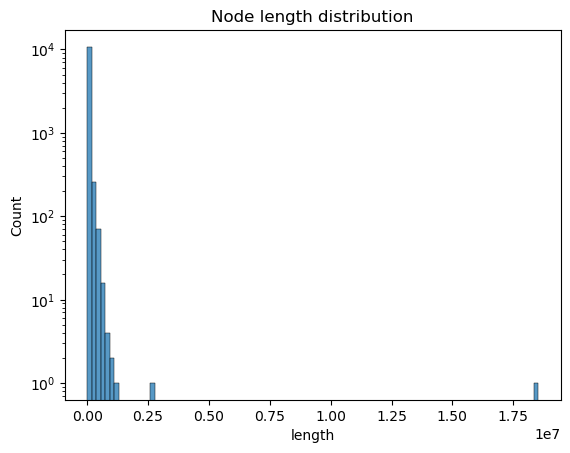

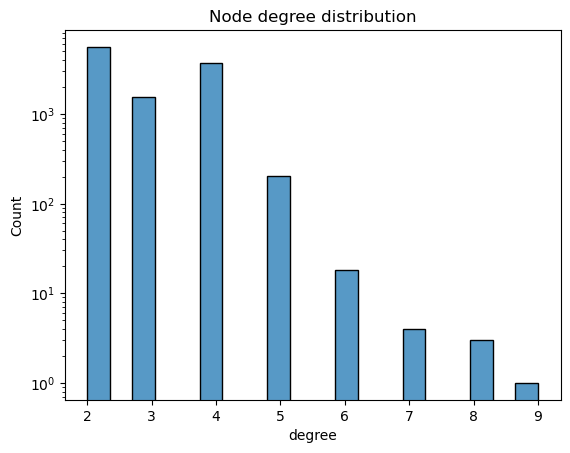

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

figs_dir = Path('figs')
figs_dir.mkdir(exist_ok=True)

df = pd.read_csv("node_metrics.tsv", sep="\t")

sns.histplot(df["length"], bins=100)
plt.yscale("log")
plt.title("Node length distribution")

plt.savefig(figs_dir / 'node_length_distribution.png')
plt.show()

sns.histplot(df["degree"], bins=20)
plt.yscale("log")
plt.title("Node degree distribution")
plt.savefig(figs_dir / 'node_degree_distribution.png')
plt.show()

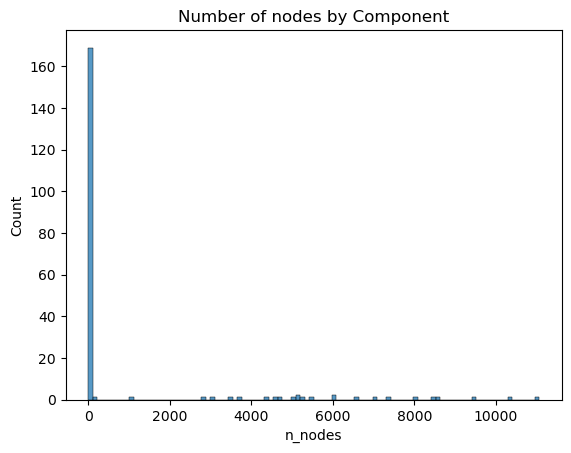

In [5]:
component_df = pd.read_csv('/home/jpereira/AAGrafos/entrega/component_metrics.tsv', sep='\t')

sns.histplot(component_df["n_nodes"], bins=100)
plt.title("Number of nodes by Component")
#plt.yscale("log")
plt.savefig(figs_dir / "hist.number_of_nodes_by_component.png")

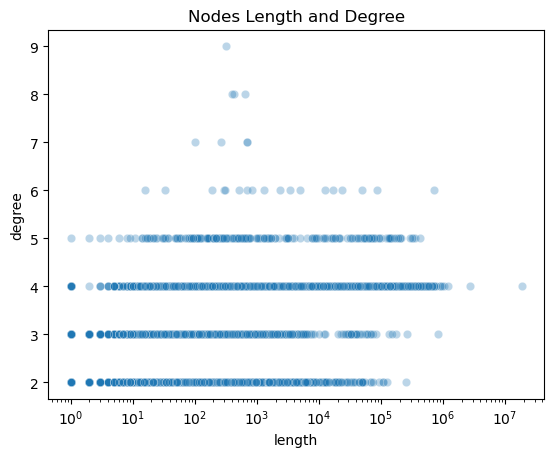

In [6]:
branch_nodes = df[df["branching"]]
sns.scatterplot(data=df, x="length", y="degree", alpha=0.3)
plt.title("Nodes Length and Degree")
plt.xscale("log")
plt.savefig(figs_dir / "scatter.nodes_length_and_degree.png")

In [7]:
ap = list(nx.articulation_points(G))

len(ap)

44138

In [8]:
bridges = list(nx.bridges(G))

pd.DataFrame(bridges, columns=["node1","node2"]).to_csv(
    "bridge_edges.tsv",
    sep="\t",
    index=False
)


AttributeError: module 'matplotlib.pyplot' has no attribute 'save'

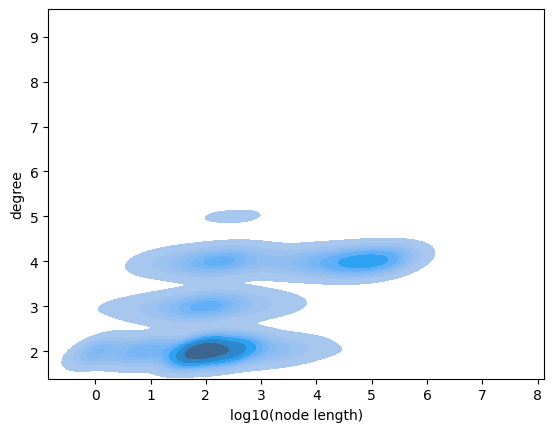

In [ ]:

df["log_length"] = np.log10(df["length"])
sns.kdeplot(
    data=df,
    x="log_length",
    y="degree",
    fill=True,
)
plt.xlabel("log10(node length)")
plt.ylabel("degree")
plt.title("KDE Biggest Component, node degree vs  node length log")
plt.savefig(figs_dir / "KDE_node_degree_vs_node_log_lengthpng")

En conjunto, estos gráficos sugieren que el componente conectado más grande del pangenoma está dominado por un backbone lineal conservado, con regiones de variación localizadas. La distribución del grado de los nodos muestra que la mayoría tiene grado 2, lo que es consistente con tramos relativamente lineales de secuencia compartida entre los genomas. Los nodos con grados mayores son menos frecuentes, lo que indica que las estructuras ramificadas existen, pero no dominan la arquitectura global del grafo.

La distribución de longitudes de los nodos muestra muchos nodos cortos y pocos nodos muy largos. Esto es típico en grafos de pangenoma: los nodos largos suelen representar regiones conservadas que pueden colapsarse en segmentos compartidos, mientras que los nodos cortos suelen corresponder a regiones variables, como variantes pequeñas, indels o ramificaciones locales. En otras palabras, el grafo parece estar compuesto por segmentos largos y conservados, junto con muchos segmentos cortos que capturan la diversidad entre ensamblajes.

La relación entre longitud y grado refuerza esta idea. Los nodos más largos tienden a tener grados bajos, mientras que los nodos cortos aparecen más frecuentemente asociados a grados más altos. Esto sugiere que la mayor parte de la variación está concentrada en segmentos cortos y en estructuras locales tipo “bubble”, insertas dentro de un backbone genómico más estable.

En resumen, el pangenoma parece tener una estructura esperable para genomas cercanamente relacionados: una gran fracción conservada, acompañada por variación localizada en regiones específicas del grafo. Los nodos con grados inusualmente altos o con combinaciones poco comunes de longitud y conectividad probablemente sean las regiones más interesantes para explorar después, ya que podrían corresponder a hotspots de variación estructural, regiones repetitivas o loci particularmente complejos.

## The follow up analyisis would try to use tools viewed in the labs 2 and 3. 

The suggested route by GPT is the following:

1. Largest connected component

2. normalized Laplacian

3. first 10 non-trivial eigenvectors

4. k-means on the first 3–5 eigenvectors

5. summary table per cluster

6. compare clusters by node length and degree


## Employing graspalogic library

/home/jpereira/miniconda3/envs/graph_vis_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nodes: 143651
Edges: 206724
Largest component nodes: 11070
Largest component edges: 15918
Adjacency matrix shape: (11070, 11070)
Embedding shape: (11070, 8)

Cluster summary


,n_nodes,mean_degree,median_degree,mean_length,median_length
cluster,,,,,
0,14,4.928571,5.0,2364.071429,142.5
1,6488,2.848335,2.0,23595.782367,171.0
2,11,2.000000,2.0,4731.636364,331.0
3,4557,2.910906,3.0,21881.209568,173.0


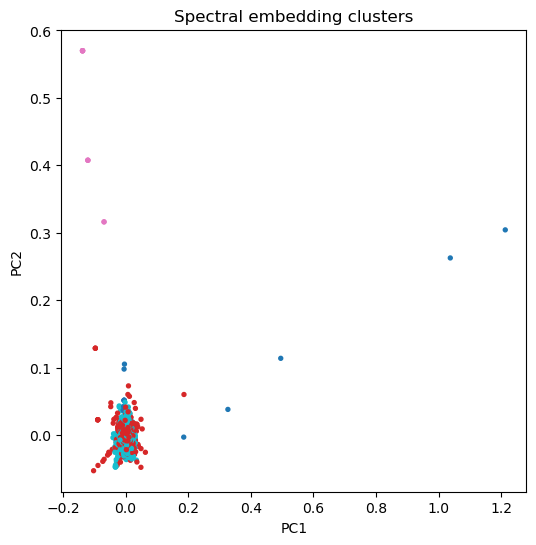

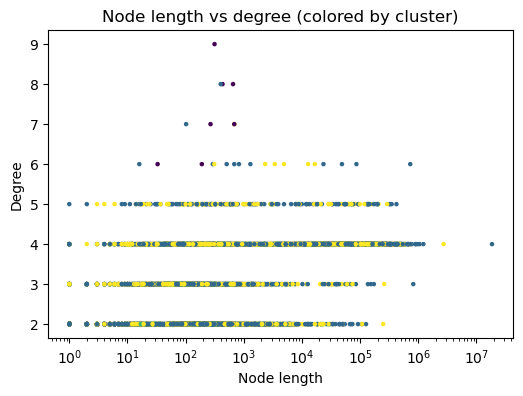

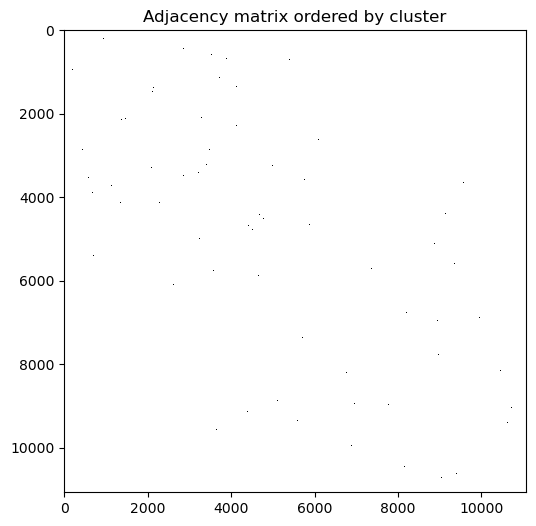

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from graspologic.embed import AdjacencySpectralEmbed
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ----------------------------
# 1. Load graph
# ----------------------------
# If already loaded, skip this
# Example:
# G = nx.read_gpickle("graph_full.pkl")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# ----------------------------
# 2. Largest connected component
# ----------------------------
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

print("Largest component nodes:", G_lcc.number_of_nodes())
print("Largest component edges:", G_lcc.number_of_edges())

# ----------------------------
# 3. Node metrics
# ----------------------------
node_list = list(G_lcc.nodes())

degrees = dict(G_lcc.degree())

# node length attribute may exist in your graph
if "length" in list(G_lcc.nodes(data=True))[0][1]:
    lengths = {n: G_lcc.nodes[n]["length"] for n in G_lcc.nodes()}
else:
    lengths = {n: 1 for n in G_lcc.nodes()}

node_df = pd.DataFrame({
    "node": node_list,
    "degree": [degrees[n] for n in node_list],
    "length": [lengths[n] for n in node_list]
})

# ----------------------------
# 4. Build adjacency matrix
# ----------------------------
A = nx.to_numpy_array(G_lcc, nodelist=node_list)

print("Adjacency matrix shape:", A.shape)

# ----------------------------
# 5. Spectral embedding
# ----------------------------
ase = AdjacencySpectralEmbed(n_components=8)

X = ase.fit_transform(A)

print("Embedding shape:", X.shape)

# ----------------------------
# 6. Clustering
# ----------------------------
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

node_df["cluster"] = labels

# ----------------------------
# 7. Cluster summary table
# ----------------------------
cluster_summary = node_df.groupby("cluster").agg(
    n_nodes=("node","count"),
    mean_degree=("degree","mean"),
    median_degree=("degree","median"),
    mean_length=("length","mean"),
    median_length=("length","median")
)

print("\nCluster summary")
display(cluster_summary)

# ----------------------------
# 8. Embedding visualization
# ----------------------------
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=labels, s=8, cmap="tab10")
plt.title("Spectral embedding clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# ----------------------------
# 9. Degree vs length plot
# ----------------------------
plt.figure(figsize=(6,4))
plt.scatter(node_df["length"], node_df["degree"], c=node_df["cluster"], s=5)
plt.xscale("log")
plt.xlabel("Node length")
plt.ylabel("Degree")
plt.title("Node length vs degree (colored by cluster)")
plt.show()

# ----------------------------
# 10. Reordered adjacency matrix
# ----------------------------
order = np.argsort(labels)

plt.figure(figsize=(6,6))
plt.imshow(A[order][:,order], cmap="Greys", interpolation="none")
plt.title("Adjacency matrix ordered by cluster")
plt.show()

# ----------------------------
# 11. Save results
# ----------------------------
node_df.to_csv("node_clusters.grapalogic.tsv", sep="\t", index=False)
cluster_summary.to_csv("cluster_summary.grapalogic.tsv", sep="\t")

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

# 1. Normalized Laplacian
L = nx.normalized_laplacian_matrix(G_lcc)
node_list = list(G_lcc.nodes())

# 2. First eigenvectors
# k asks for total eigenvectors; the first one is usually trivial
eigenvalues, eigenvectors = eigsh(L, k=200, which="SM")

# sort just in case
order = np.argsort(eigenvalues)
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# 3. Build spectral embedding from non-trivial eigenvectors
# skip the first column (trivial eigenvector)
X = eigenvectors[:, 1:190]

# 4. Run k-means
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

# 5. Save node labels
cluster_df = pd.DataFrame({
    "node": node_list,
    "cluster": labels
})

cluster_df.to_csv("spectral_node_labels.tsv", sep="\t", index=False)

In [ ]:
node_metrics = []

for node in node_list:
    degree = G_lcc.degree(node)
    length = G_lcc.nodes[node].get("length", np.nan)

    node_metrics.append({
        "node": node,
        "degree": degree,
        "length": length,
        "branching": degree > 2,
        "terminal": degree == 1
    })

node_metrics_df = pd.DataFrame(node_metrics)

cluster_node_df = cluster_df.merge(node_metrics_df, on="node", how="left")

In [ ]:
cluster_summary = (
    cluster_node_df
    .groupby("cluster")
    .agg(
        n_nodes=("node", "count"),
        mean_degree=("degree", "mean"),
        median_degree=("degree", "median"),
        max_degree=("degree", "max"),
        mean_length=("length", "mean"),
        median_length=("length", "median"),
        total_length=("length", "sum"),
        branching_fraction=("branching", "mean"),
        terminal_fraction=("terminal", "mean")
    )
    .reset_index()
)

cluster_summary.to_csv("spectral_cluster_summary.tsv", sep="\t", index=False)
cluster_summary

,cluster,n_nodes,mean_degree,median_degree,max_degree,mean_length,median_length,total_length,branching_fraction,terminal_fraction
0,0,90,2.977778,3.0,5,33494.444444,175.0,3014500,0.555556,0.0
1,1,10727,2.874709,2.0,9,23203.523073,173.0,248904192,0.494080,0.0
2,2,116,2.896552,3.0,5,3642.724138,141.5,422556,0.551724,0.0
3,3,137,2.883212,3.0,6,3985.437956,123.0,546005,0.518248,0.0


In [ ]:
cluster_graph_rows = []

for c in sorted(cluster_df["cluster"].unique()):
    members = cluster_df.loc[cluster_df["cluster"] == c, "node"]
    sub = G_lcc.subgraph(members)

    cluster_graph_rows.append({
        "cluster": c,
        "subgraph_nodes": sub.number_of_nodes(),
        "subgraph_edges": sub.number_of_edges(),
        "density": nx.density(sub) if sub.number_of_nodes() > 1 else np.nan,
        "n_components": nx.number_connected_components(sub) if sub.number_of_nodes() > 0 else np.nan
    })

cluster_graph_df = pd.DataFrame(cluster_graph_rows)
cluster_summary = cluster_summary.merge(cluster_graph_df, on="cluster", how="left")
cluster_summary.to_csv("spectral_cluster_summary.tsv", sep="\t", index=False)
cluster_summary

,cluster,n_nodes,mean_degree,median_degree,max_degree,mean_length,median_length,total_length,branching_fraction,terminal_fraction,subgraph_nodes,subgraph_edges,density,n_components
0,0,90,2.977778,3.0,5,33494.444444,175.0,3014500,0.555556,0.0,90,127,0.031710,2
1,1,10727,2.874709,2.0,9,23203.523073,173.0,248904192,0.494080,0.0,10727,15398,0.000268,18
2,2,116,2.896552,3.0,5,3642.724138,141.5,422556,0.551724,0.0,116,160,0.023988,3
3,3,137,2.883212,3.0,6,3985.437956,123.0,546005,0.518248,0.0,137,192,0.020610,2


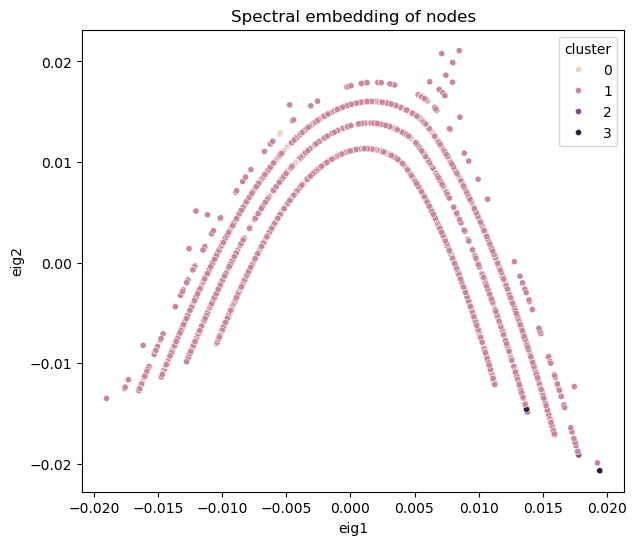

In [ ]:
embedding_df = pd.DataFrame({
    "node": node_list,
    "cluster": labels,
    "eig1": X[:, 0],
    "eig2": X[:, 1],
    "eig3": X[:, 2],
    "eig4": X[:, 3],
})

plt.figure(figsize=(7, 6))
sns.scatterplot(data=embedding_df, x="eig1", y="eig2", hue="cluster", s=20)
plt.title("Spectral embedding of nodes")
plt.show()

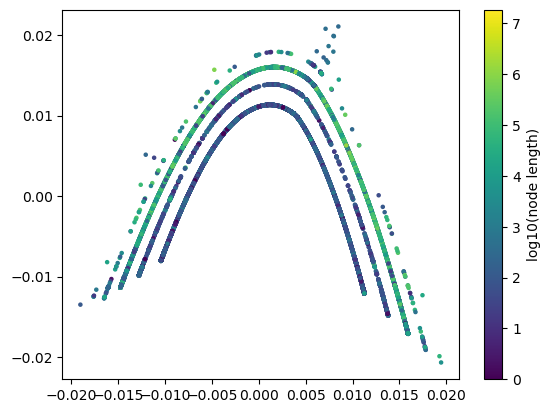

In [ ]:
lengths = [G_lcc.nodes[n]["length"] for n in node_list]
plt.scatter(X[:,0], X[:,1], c=np.log10(lengths), s=5, cmap="viridis")
plt.colorbar(label="log10(node length)")

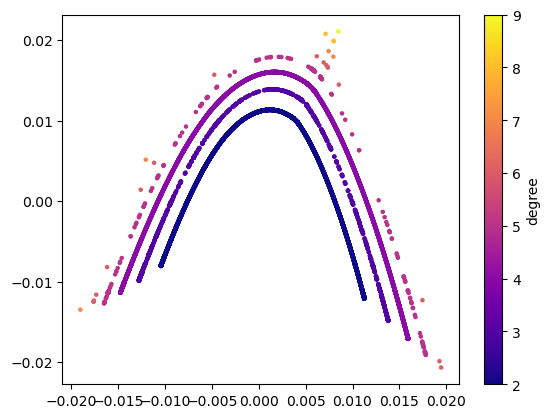

In [ ]:
degrees = np.array([G_lcc.degree(n) for n in node_list])
plt.scatter(X[:,0], X[:,1], c=degrees, s=5, cmap="plasma")
plt.colorbar(label="degree")

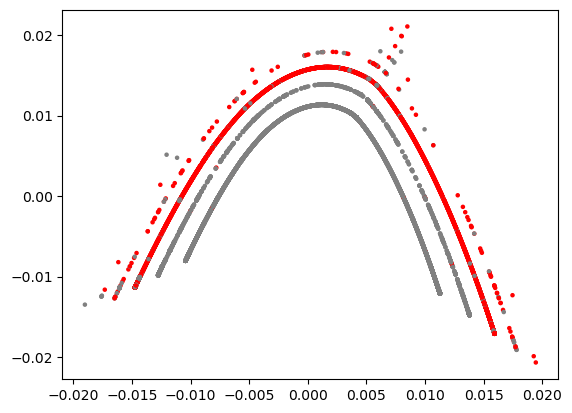

In [ ]:
art = set(nx.articulation_points(G_lcc))

colors = ["red" if node in art else "gray" for node in node_list]

plt.scatter(X[:,0], X[:,1], c=colors, s=5)